## Phase 2 — Behavioral Segmentation

### Why segment before predicting?

A global predictive model tells you "this employee has a 70% probability of 
leaving." Useful, but limited: it does not say *why*, nor *what type* of 
employee this is.

Consider three employees with the same attrition probability:
- **Profile A:** young, overloaded, satisfied with their role but burned out
- **Profile B:** tenured employee, career-stagnant, no promotions in years
- **Profile C:** high performer with a direct conflict with their manager

All three are likely to leave — but for entirely different reasons. An effective 
intervention for A (workload reduction) is irrelevant for B (career development) 
and useless for C (management change). Clustering reveals those profiles *before* 
the predictive model flattens them into a single probability score.

---

### 2.1 — Clustering variable selection

We do not cluster on all variables. Only the behavioral and psychometric block 
is used. This is a deliberate design decision: we want profiles based on *how 
employees experience their work*, not on who they are demographically or how 
much they earn.

**Selected variables:**

| Variable | Dimension | Range | Mean |
|----------|-----------|-------|------|
| JobSatisfaction | Satisfaction with job content | 1–4 | 2.73 |
| EnvironmentSatisfaction | Satisfaction with physical/social environment | 1–4 | 2.72 |
| RelationshipSatisfaction | Satisfaction with interpersonal relationships | 1–4 | 2.71 |
| JobInvolvement | Engagement / involvement level | 1–4 | 2.73 |
| WorkLifeBalance | Perceived work-life balance | 1–4 | 2.76 |
| OverTimeBinary | Structural overload indicator | 0–1 | 0.28 |

**Finding:** all five psychometric variables show nearly identical means (~2.73), 
slightly below the scale midpoint. No single dimension stands out globally. 
28% of employees report working overtime.

---

### 2.2 — Feature scaling

K-Means measures distances between employees. Without scaling, a 1-point 
difference in `JobSatisfaction` (range 1–4) and a 1-point difference in 
`OverTimeBinary` (range 0–1) would carry identical numerical weight — despite 
representing very different magnitudes.

`StandardScaler` transforms each variable to mean = 0 and standard deviation = 1, 
placing all dimensions on the same numerical scale before distance computation.

**Post-scaling verification:** all variables confirmed at mean ≈ 0.0, std = 1.0.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Carga
df = pd.read_csv('../data/raw/HR-Employee-Attrition.csv')
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)
df['AttritionBinary'] = (df['Attrition'] == 'Yes').astype(int)
df['OverTimeBinary'] = (df['OverTime'] == 'Yes').astype(int)

# Espacio de clustering: solo variables conductuales y psicométricas
clustering_vars = [
    'JobSatisfaction',        # Satisfacción con el contenido del trabajo
    'EnvironmentSatisfaction', # Satisfacción con el entorno físico/social
    'RelationshipSatisfaction',# Satisfacción con relaciones interpersonales
    'JobInvolvement',         # Nivel de involucramiento/engagement
    'WorkLifeBalance',        # Percepción de balance vida-trabajo
    'OverTimeBinary',         # Sobrecarga estructural (0/1)
]

df_cluster = df[clustering_vars].copy()

print('Variables seleccionadas para clustering:')
for v in clustering_vars:
    print(f'  {v}: rango {df_cluster[v].min()}–{df_cluster[v].max()}, '
          f'media {df_cluster[v].mean():.2f}')

Variables seleccionadas para clustering:
  JobSatisfaction: rango 1–4, media 2.73
  EnvironmentSatisfaction: rango 1–4, media 2.72
  RelationshipSatisfaction: rango 1–4, media 2.71
  JobInvolvement: rango 1–4, media 2.73
  WorkLifeBalance: rango 1–4, media 2.76
  OverTimeBinary: rango 0–1, media 0.28


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_cluster),
    columns=clustering_vars
)

print('Verificación post-escalado (media y std por variable):')
print(df_scaled.describe().loc[['mean', 'std']].round(3))

Verificación post-escalado (media y std por variable):
      JobSatisfaction  EnvironmentSatisfaction  RelationshipSatisfaction  \
mean             -0.0                      0.0                       0.0   
std               1.0                      1.0                       1.0   

      JobInvolvement  WorkLifeBalance  OverTimeBinary  
mean             0.0             -0.0            -0.0  
std              1.0              1.0             1.0  


### 2.3 — Determining the optimal number of clusters

Two complementary metrics were used to select k: the **elbow method** (inertia)
and the **Silhouette Score**.

**Inertia** measures internal cluster compactness — the sum of distances from 
each employee to their cluster centroid. It always decreases as k increases, 
so we look for the "elbow": the point where adding more clusters yields 
diminishing returns.

**Silhouette Score** measures how well-separated clusters are from each other.
For each employee it computes:
- `a` = average distance to all members of their own cluster
- `b` = average distance to all members of the nearest neighboring cluster
- `silhouette = (b - a) / max(a, b)`

A score near 1.0 means the employee is well-placed in their cluster. Near 0.0 
means they sit on a boundary. Negative means they may belong to a different cluster.

**Results:**

| k | Silhouette Score |
|---|-----------------|
| 2 | 0.2064 |
| 3 | 0.1676 |
| 4 | 0.1635 |
| 5 | 0.1471 |
| 6 | 0.1475 |
| 7 | 0.1640 |
| 8 | 0.1654 |
| 9 | 0.1706 |
| 10 | 0.1642 |

**Methodological note:** scores range between 0.15–0.21, which is modest.
This is not a failure of the method — it reflects a genuine characteristic 
of the data. Organizational attitudes measured on 4-point Likert scales tend 
to be continuously distributed rather than naturally clustered into discrete 
islands. Employees do not fall into sharply separated groups; they occupy 
a relatively continuous behavioral space.

**Decision: k = 4.** While k=2 yields the highest Silhouette Score, two 
groups offer insufficient resolution for organizational intervention — the 
distinction would collapse to "at-risk vs. not at-risk," which adds nothing 
beyond the predictive model. Four behavioral profiles represent a meaningful 
and communicable segmentation for HR practitioners, with inertia already 
substantially reduced from k=2 and silhouette remaining stable.

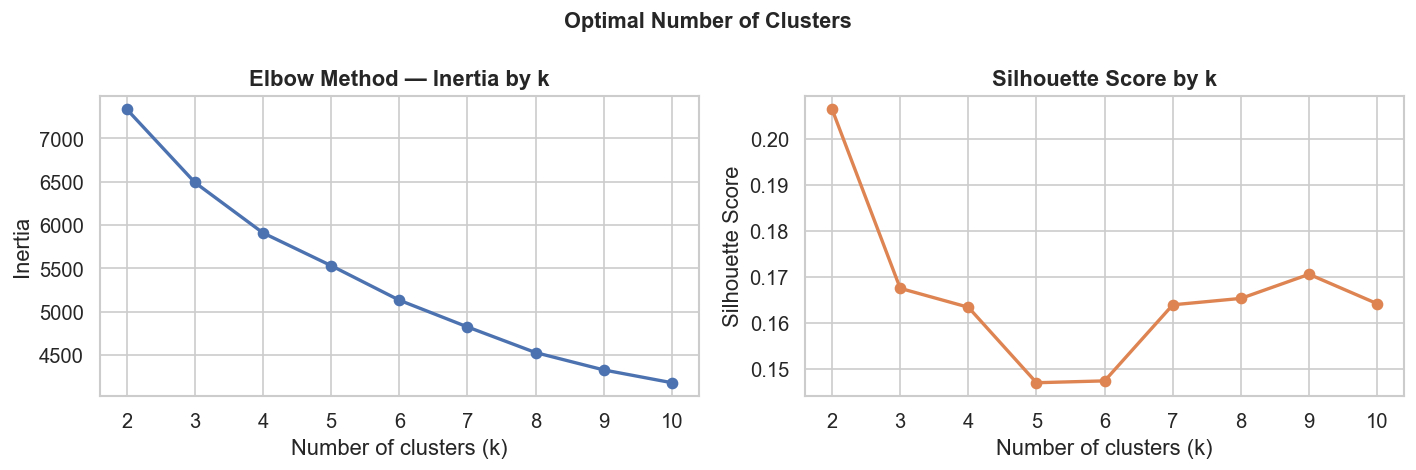

Silhouette scores:
  k=2: 0.2064
  k=3: 0.1676
  k=4: 0.1635
  k=5: 0.1471
  k=6: 0.1475
  k=7: 0.1640
  k=8: 0.1654
  k=9: 0.1706
  k=10: 0.1642


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Método del codo
axes[0].plot(k_range, inertias, 'o-', color='#4C72B0', linewidth=2)
axes[0].set_title('Elbow Method — Inertia by k', fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'o-', color='#DD8452', linewidth=2)
axes[1].set_title('Silhouette Score by k', fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

plt.suptitle('Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/06_optimal_clusters.png')
plt.show()

print('Silhouette scores:')
for k, s in zip(k_range, silhouette_scores):
    print(f'  k={k}: {s:.4f}')

### 2.4 — Cluster assignment and attrition validation

K-Means final model fitted with k=4, random_state=42, n_init=10.

**Cluster distribution:**

| Cluster | N | % of total | Attrition rate |
|---------|---|------------|----------------|
| 0 | 278 | 18.9% | 16.2% |
| 1 | 350 | 23.8% | 10.6% |
| 2 | 394 | 26.8% | **29.7%** |
| 3 | 448 | 30.5% | 8.5% |
| **Total** | **1,470** | **100%** | **16.1%** |

**Validation finding:** attrition rates vary substantially across clusters —
from 8.5% to 29.7% against a global baseline of 16.1%. Cluster 2 shows nearly
double the global rate; Cluster 3 shows nearly half. This confirms that the
behavioral and psychometric variables capture meaningful variance in attrition
risk. The segmentation is organizationally valid.

What drives these differences is examined in the centroid analysis below.

In [7]:
from sklearn.cluster import KMeans

# Modelo final con k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

# Distribución de empleados por cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
print('Employees per cluster:')
for cluster, count in cluster_counts.items():
    pct = count / len(df) * 100
    print(f'  Cluster {cluster}: {count} employees ({pct:.1f}%)')

# Tasa de attrition por cluster — primera señal de si los grupos son relevantes
print('\nAttrition rate by cluster:')
attrition_by_cluster = df.groupby('Cluster')['AttritionBinary'].mean() * 100
for cluster, rate in attrition_by_cluster.items():
    print(f'  Cluster {cluster}: {rate:.1f}%')

Employees per cluster:
  Cluster 0: 278 employees (18.9%)
  Cluster 1: 350 employees (23.8%)
  Cluster 2: 394 employees (26.8%)
  Cluster 3: 448 employees (30.5%)

Attrition rate by cluster:
  Cluster 0: 16.2%
  Cluster 1: 10.6%
  Cluster 2: 29.7%
  Cluster 3: 8.5%


### 2.5 — Centroid analysis and profile naming

Cluster centroids represent the "average employee" of each group in the 
six-dimensional behavioral space. Analyzed in original scale for interpretability.

**Key finding:** `JobSatisfaction`, `EnvironmentSatisfaction`, and `JobInvolvement` 
are nearly identical across all four clusters (range: 2.67–2.84). These variables 
do not differentiate behavioral profiles. The clustering structure is driven 
entirely by three variables: `OverTimeBinary`, `WorkLifeBalance`, and 
`RelationshipSatisfaction`.

**Behavioral profiles:**

| Cluster | Profile name | Attrition | N | Defining characteristics |
|---------|-------------|-----------|---|--------------------------|
| 0 | Strained but Present | 16.2% | 278 | Lowest WorkLifeBalance (1.71), minimal overtime |
| 1 | Structurally Stable, Relationally Distant | 10.6% | 350 | Lowest RelationshipSatisfaction (1.45), zero overtime |
| 2 | Overloaded at Risk | 29.7% | 394 | OverTime = 1.00 (100%), near-double attrition rate |
| 3 | Engaged and Balanced | 8.5% | 448 | Highest RelationshipSatisfaction (3.50) and WorkLifeBalance (3.15) |

**Organizational implication:** attrition risk in this dataset is not primarily 
attitudinal — employees do not leave because they dislike their job content or 
environment uniformly across groups. Risk is driven by structural overload 
(Cluster 2), perceived work-life imbalance (Cluster 0), and conversely protected 
by strong relationships and balance (Cluster 3). This has direct implications 
for intervention design: generic satisfaction surveys will not detect the 
primary risk drivers identified here.

In [8]:
# Centroides en escala original
centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=clustering_vars
)
centroids_original.index.name = 'Cluster'

# Agregar tasa de attrition y tamaño
centroids_original['Attrition_rate_%'] = (
    df.groupby('Cluster')['AttritionBinary'].mean() * 100
).round(1).values

centroids_original['N_employees'] = (
    df.groupby('Cluster').size()
).values

print('Cluster centroids (original scale):\n')
print(centroids_original.round(2).to_string())

Cluster centroids (original scale):

         JobSatisfaction  EnvironmentSatisfaction  RelationshipSatisfaction  JobInvolvement  WorkLifeBalance  OverTimeBinary  Attrition_rate_%  N_employees
Cluster                                                                                                                                                    
0                   2.80                     2.67                      2.93            2.78             1.71            0.08              16.2          278
1                   2.74                     2.68                      1.45            2.68             3.02            0.00              10.6          350
2                   2.74                     2.84                      2.78            2.72             2.83            1.00              29.7          394
3                   2.67                     2.68                      3.50            2.74             3.15            0.00               8.5          448


### 2.6 — Behavioral profile visualization

Two complementary visualizations summarize the segmentation results.

The **centroid heatmap** displays the mean value of each behavioral variable 
per profile. The color scale (red = low, green = high) makes cross-profile 
patterns immediately visible without reading individual values.

The **attrition rate chart** plots each profile's rotation rate against the 
global baseline (16.1%), with color intensity reflecting risk level.

**Visual findings:**
- `OverTimeBinary` in *Overloaded at Risk* is the single most visually 
  distinctive cell in the heatmap — value 1.00, darkest red. No other profile 
  shows meaningful overtime.
- `WorkLifeBalance` in *Strained but Present* is the only profile with low 
  balance perception (1.71) in the absence of formal overtime — suggesting 
  unmeasured sources of strain.
- `RelationshipSatisfaction` in *Structurally Stable, Relationally Distant* 
  is the lowest across all profiles (1.45), yet this group shows below-average 
  attrition — structural comfort compensates for relational dissatisfaction.
- `JobSatisfaction`, `EnvironmentSatisfaction`, and `JobInvolvement` show 
  uniform green across all profiles, confirming they do not drive segmentation.

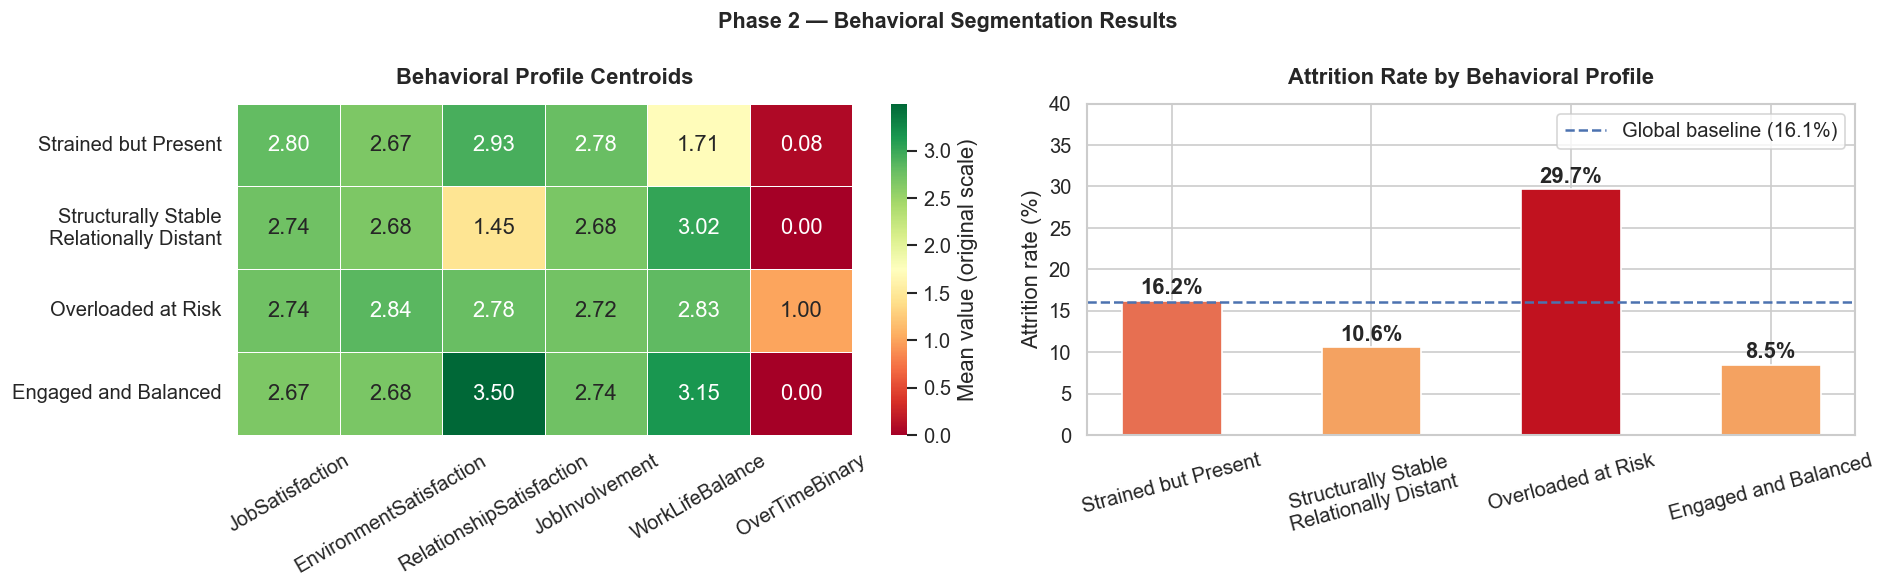

In [9]:
# Nombres de perfiles
profile_names = {
    0: 'Strained but Present',
    1: 'Structurally Stable\nRelationally Distant',
    2: 'Overloaded at Risk',
    3: 'Engaged and Balanced'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Heatmap de centroides ---
heatmap_data = centroids_original[clustering_vars].copy()
heatmap_data.index = [profile_names[i] for i in heatmap_data.index]

sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': 'Mean value (original scale)'}
)
axes[0].set_title('Behavioral Profile Centroids', fontweight='bold', pad=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# --- Attrition por perfil ---
profile_labels = [profile_names[i] for i in sorted(profile_names.keys())]
attrition_rates = centroids_original['Attrition_rate_%'].values
colors = ['#f4a261' if r < 16 else '#e76f51' if r < 25 else '#c1121f'
          for r in attrition_rates]

bars = axes[1].bar(profile_labels, attrition_rates, color=colors,
                   edgecolor='white', width=0.5)
axes[1].axhline(y=16.1, color='#4C72B0', linestyle='--',
                linewidth=1.5, label='Global baseline (16.1%)')
axes[1].set_title('Attrition Rate by Behavioral Profile', fontweight='bold', pad=12)
axes[1].set_ylabel('Attrition rate (%)')
axes[1].set_ylim(0, 40)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

for bar, rate in zip(bars, attrition_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f'{rate:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Phase 2 — Behavioral Segmentation Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_behavioral_profiles.png')
plt.show()